In [6]:
import pickle
import gzip
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple

# Define the dataclasses to match the training data structure
@dataclass
class TrainingExample:
    unpadded_example_sequence: list 
    actual_pace_seconds: float
    raw_pace_data: list

@dataclass
class RunnerForTraining:
    name_gender_dedup_int: Tuple[str, str, str, int]  # (first_name, last_name, gender, dedup_int)
    training_examples: List[TrainingExample]
    split_assignment: int

# Target runners to find
target_runners = [
    ("Romain", "Yon"),
    ("Yael", "Elmatad"),
    ("Rafal", "Wojdyla")
]

print("Target runners to find:")
for first, last in target_runners:
    print(f"  - {first} {last}")
print()


Target runners to find:
  - Romain Yon
  - Yael Elmatad
  - Rafal Wojdyla



In [3]:
# Load all training splits
splits_dir = Path("../pipeline/training_splits")
if not splits_dir.exists():
    raise FileNotFoundError(f"Training splits directory not found: {splits_dir}")

split_files = sorted(list(splits_dir.glob("*.pkl.gz")))
print(f"Found {len(split_files)} training split files")
print(f"Loading all runners...")
print()

all_runners = []
found_runners = {name: None for name in target_runners}

for file_idx, fpath in enumerate(split_files):
    if (file_idx + 1) % 10 == 0:
        print(f"  Processed {file_idx + 1}/{len(split_files)} files...")
    
    with gzip.open(fpath, 'rb') as f:
        while True:
            try:
                batch = pickle.load(f)
                for runner in batch:
                    all_runners.append(runner)
                    
                    # Check if this runner matches any target
                    name_tuple = runner.name_gender_dedup_int
                    first_name = name_tuple[0]
                    last_name = name_tuple[1]
                    
                    for target_first, target_last in target_runners:
                        if (first_name.lower() == target_first.lower() and 
                            last_name.lower() == target_last.lower()):
                            found_runners[(target_first, target_last)] = runner
                            print(f"  ✓ Found: {first_name} {last_name} (gender: {name_tuple[2]}, dedup: {name_tuple[3]})")
                            
            except EOFError:
                break

print()
print(f"Total runners loaded: {len(all_runners)}")
print()


Found 100 training split files
Loading all runners...

  ✓ Found: Yael Elmatad (gender: W, dedup: 0)
  ✓ Found: Rafal Wojdyla (gender: M, dedup: 0)
  Processed 10/100 files...
  Processed 20/100 files...
  Processed 30/100 files...
  Processed 40/100 files...
  Processed 50/100 files...
  Processed 60/100 files...
  Processed 70/100 files...
  Processed 80/100 files...
  ✓ Found: Romain Yon (gender: M, dedup: 0)
  Processed 90/100 files...
  Processed 100/100 files...

Total runners loaded: 593614



In [24]:
# Display information about found runners
print("=" * 80)
print("FOUND RUNNERS SUMMARY")
print("=" * 80)
print()

for (target_first, target_last), runner in found_runners.items():
    if runner is None:
        print(f"❌ {target_first} {target_last}: NOT FOUND")
        print()
        continue
    
    name_tuple = runner.name_gender_dedup_int
    first_name, last_name, gender, dedup_int = name_tuple
    
    print(f"✓ {first_name} {last_name}")
    print(f"  Gender: {gender}")
    print(f"  Dedup ID: {dedup_int}")
    print(f"  Split Assignment: {runner.split_assignment}")
    print(f"  Number of Training Examples: {len(runner.training_examples)}")
    print()
    
    # Show details of each training example
    for ex_idx, ex in enumerate(runner.training_examples):
        seq_len = len(ex.unpadded_example_sequence)
        n_races = seq_len // 11  # Assuming 11 tokens per race block
        print(f"  Example {ex_idx + 1}:")
        print(f"    Sequence length: {seq_len} tokens ({n_races} races)")
        print(f"    Actual pace: {ex.actual_pace_seconds:.1f} seconds")
        print(f"    Raw pace data entries: {len(ex.raw_pace_data)}")
        if ex.raw_pace_data:
            print(f"    First race pace: {ex.raw_pace_data[0]}")
            print(f"    Last race pace: {ex.raw_pace_data[-1]}")
        print()
    
    print("-" * 80)
    print()


FOUND RUNNERS SUMMARY



NameError: name 'found_runners' is not defined

In [25]:
# Store found runners for further analysis
found_runners_dict = {
    f"{first} {last}": runner 
    for (first, last), runner in found_runners.items() 
    if runner is not None
}

print(f"Found {len(found_runners_dict)} out of {len(target_runners)} target runners")
print()
print("Available in 'found_runners_dict' variable for further analysis")


NameError: name 'found_runners' is not defined

In [6]:
# Save found runners to pickle file
output_path = Path("../../data/yael-romain-rafal.pickle")
output_path.parent.mkdir(parents=True, exist_ok=True)

# Save the found_runners_dict (only runners that were found)
with open(output_path, 'wb') as f:
    pickle.dump(found_runners_dict, f)

print(f"✓ Saved {len(found_runners_dict)} runners to: {output_path}")
print()
print("Runners saved:")
for name in found_runners_dict.keys():
    print(f"  - {name}")


✓ Saved 3 runners to: ../../data/yael-romain-rafal.pickle

Runners saved:
  - Romain Yon
  - Yael Elmatad
  - Rafal Wojdyla


In [26]:
pickle_path = Path("/Users/yaelelmatad/Desktop/nyrr-transform/Runtime/data/yael-romain-rafal.pickle")
if pickle_path.exists():
    with open(pickle_path, 'rb') as f:
        found_runners_dict = pickle.load(f)
    
    print(f"✓ Loaded {len(found_runners_dict)} runners from: {pickle_path}")
    print()
    print("Loaded runners:")
    for name in found_runners_dict.keys():
        runner = found_runners_dict[name]
        print(f"  - {name}: {len(runner.training_examples)} training examples")
    print()
    print("Available in 'found_runners_dict' variable for further analysis")
else:
    print(f"❌ Pickle file not found: {pickle_path}")
    print("   Please run the previous cell to create the pickle file first.")


✓ Loaded 3 runners from: /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/data/yael-romain-rafal.pickle

Loaded runners:
  - Romain Yon: 9 training examples
  - Yael Elmatad: 29 training examples
  - Rafal Wojdyla: 13 training examples

Available in 'found_runners_dict' variable for further analysis


In [27]:
# Load model and necessary components for predictions
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'  # Enable CPU fallback for MPS unsupported ops

import torch
import torch.nn as nn
import yaml
import math
import numpy as np
from scipy.interpolate import pchip_interpolate
import pickle

# Paths
CHECKPOINT_PATH = "/Users/yaelelmatad/Desktop/nyrr-transform/Production_Scale_v2_HighCap/best_model.pt"
CONFIG_PATH = "/Users/yaelelmatad/Desktop/nyrr-transform/Production_Scale_v2_HighCap/config_copy.yaml"
PACE_LOOKUP_PATH = "/Users/yaelelmatad/Desktop/nyrr-transform/Runtime/data/pace_lookup.pickle"
DEVICE = torch.device("cpu")  # Use CPU to avoid MPS issues

# Model architecture
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class RunTimeTransformer(nn.Module):
    def __init__(self, vocab_size, num_pace_bins, config):
        super().__init__()
        m = config['model']
        self.d_model = m['d_model']
        self.embedding = nn.Embedding(vocab_size, self.d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(self.d_model, m['max_seq_length'])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=m['nhead'], 
            dim_feedforward=m['dim_feedforward'], 
            dropout=m['dropout'], 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=m['num_layers'])
        self.transformer.enable_nested_tensor = False
        self.output_head = nn.Linear(self.d_model, num_pace_bins)
        self._init_weights()
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)
        nn.init.constant_(self.output_head.bias, 0)
    def forward(self, x, padding_mask):
        sz = x.size(1)
        causal_mask = torch.triu(torch.ones(sz, sz), diagonal=1).bool().to(x.device)
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        x = self.transformer(x, mask=causal_mask, src_key_padding_mask=padding_mask)
        valid_lens = (~padding_mask).sum(dim=1) - 1
        return self.output_head(x[torch.arange(x.size(0)), valid_lens])

# Load checkpoint and config
print("Loading model...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
VOCAB = checkpoint.get('vocab', {})
STATE_DICT = checkpoint.get('model_state_dict')

with open(PACE_LOOKUP_PATH, 'rb') as f: 
    pace_lookup = pickle.load(f)

bins = []
for token, info in pace_lookup.items():
    if not isinstance(info, dict): continue
    med = info.get('median_pace') or info.get('median', 0)
    bins.append({'token': token, 'start': float(info['start']), 'end': float(info['end']), 'median': float(med)})
pace_bins = sorted(bins, key=lambda x: x['median'])

with open(CONFIG_PATH, 'r') as f: 
    CONFIG = yaml.safe_load(f)
MAX_LEN = CONFIG['model']['max_seq_length']
IS_SWAPPED = CONFIG['model'].get('architecture') == 'swapped-tokens' or 'swapped' in CHECKPOINT_PATH.lower()

model = RunTimeTransformer(len(VOCAB), len(pace_bins), config=CONFIG).to(DEVICE)
model.load_state_dict(STATE_DICT)
model.eval()

pace_values = np.array([b['median'] for b in pace_bins])
for i in range(1, len(pace_values)):
    if pace_values[i] <= pace_values[i-1]:
        pace_values[i] = pace_values[i-1] + 0.0001
pace_widths = np.array([b['end'] - b['start'] for b in pace_bins])

print(f"✅ Model loaded on {DEVICE}")
print(f"   Vocab size: {len(VOCAB)}")
print(f"   Pace bins: {len(pace_bins)}")
print(f"   Max sequence length: {MAX_LEN}")


Loading model...
✅ Model loaded on cpu
   Vocab size: 733
   Pace bins: 274
   Max sequence length: 329


In [28]:
import matplotlib.pyplot as plt
import numpy as np

def prepare_inference_sequence(ex, max_len, is_swapped):
    """Prepare sequence for inference, handling swapped token architecture if needed."""
    full_sequence = ex.unpadded_example_sequence
    if is_swapped:
        rearranged = []
        for i in range(0, len(full_sequence), 11):
            block = full_sequence[i:i+11]
            if len(block) < 11: continue
            swapped_block = block[0:8] + [block[10]] + [block[8]] + [block[9]]
            rearranged.extend(swapped_block)
        X_tokens = rearranged[:-3]
    else:
        X_tokens = full_sequence[:-1]
    if len(X_tokens) > max_len: 
        X_tokens = X_tokens[-max_len:]
    return X_tokens

def predict_pace_distribution(ex):
    """Run model inference on a training example and return the pace distribution."""
    X_tokens = prepare_inference_sequence(ex, MAX_LEN, IS_SWAPPED)
    input_ids = [VOCAB.get(t, VOCAB.get('<unk>', 0)) for t in X_tokens]
    input_tensor = torch.tensor([input_ids + [0]*(MAX_LEN-len(input_ids))], dtype=torch.long).to(DEVICE)
    mask = (input_tensor == 0)
    
    with torch.no_grad():
        logits = model(input_tensor, padding_mask=mask)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    p_probs = np.maximum(0, probs)
    p_density = p_probs / pace_widths
    p_mass = p_probs / p_probs.sum() if p_probs.sum() > 0 else p_probs

    # Mode via PCHIP (Interpolated peak)
    pace_fine = np.linspace(pace_values.min(), pace_values.max(), 1000)
    dens_fine = pchip_interpolate(pace_values, p_density, pace_fine)
    dens_fine = np.maximum(0, dens_fine)
    mode_pace = pace_fine[np.argmax(dens_fine)]

    # Mean/Median via raw mass
    weighted_mean = np.sum(p_mass * pace_values)
    weighted_median = pace_values[min(np.searchsorted(np.cumsum(p_mass), 0.5), len(pace_values)-1)]
    
    return {
        'probs': p_probs,
        'density': p_density,
        'pace_values': pace_values,
        'pace_widths': pace_widths,
        'weighted_mean': weighted_mean,
        'weighted_median': weighted_median,
        'mode_pace': mode_pace,
        'fine_pace': pace_fine,
        'fine_density': dens_fine
    }

def compute_quantile(actual_pace, pred_result, pace_bins):
    """Compute the quantile (percentile) of actual_pace relative to the predicted distribution."""
    p_probs = pred_result['probs']
    bin_starts = np.array([b['start'] for b in pace_bins])
    bin_ends = np.array([b['end'] for b in pace_bins])
    p_probs_normalized = p_probs / p_probs.sum() if p_probs.sum() > 0 else p_probs
    cdf_at_bin_ends = np.cumsum(p_probs_normalized)
    
    if actual_pace < bin_starts[0]:
        percentile = 0.0
    elif actual_pace >= bin_ends[-1]:
        percentile = 100.0
    else:
        bin_idx = np.searchsorted(bin_ends, actual_pace)
        if bin_idx == 0:
            percentile = 0.0
        elif bin_idx >= len(bin_ends):
            percentile = 100.0
        else:
            cdf_at_start = cdf_at_bin_ends[bin_idx - 1] if bin_idx > 0 else 0.0
            cdf_at_end = cdf_at_bin_ends[bin_idx]
            bin_start = bin_starts[bin_idx]
            bin_end = bin_ends[bin_idx]
            if bin_end > bin_start:
                fraction = (actual_pace - bin_start) / (bin_end - bin_start)
                cdf_at_actual = cdf_at_start + fraction * (cdf_at_end - cdf_at_start)
            else:
                cdf_at_actual = cdf_at_end
            percentile = cdf_at_actual * 100.0
    return percentile

def format_seconds_to_mmss(seconds):
    """Convert seconds to MM:SS format."""
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes}:{secs:02d}"

def format_distance_token(distance_token):
    """Format distance token to readable string."""
    if not distance_token:
        return "Unknown Distance"
    # Remove 'distance_name_token_' prefix if present
    if distance_token.startswith('distance_name_token_'):
        distance = distance_token.replace('distance_name_token_', '')
        # Replace underscores with spaces and capitalize
        distance = distance.replace('_', ' ').title()
        return distance
    return distance_token

def format_week_delta(week_delta_token):
    """Extract and format week delta from token like 'week_delta_140'."""
    if not week_delta_token:
        return "Unknown"
    if isinstance(week_delta_token, str) and week_delta_token.startswith('week_delta_'):
        try:
            weeks = int(week_delta_token.replace('week_delta_', ''))
            return f"{weeks}w"
        except ValueError:
            return week_delta_token
    return str(week_delta_token)

def plot_prediction_with_quantile(ex, runner_name="", example_num=0, quantile=None, ax=None):
    """Plot the prediction distribution and annotate the quantile of the actual result.
    
    Args:
        ex: TrainingExample
        runner_name: Name of the runner
        example_num: Example number
        quantile: Precomputed quantile (optional)
        ax: Matplotlib axis to plot on (if None, creates new figure)
    
    Returns:
        quantile: The computed quantile
    """
    X_tokens = prepare_inference_sequence(ex, MAX_LEN, IS_SWAPPED)
    num_races = (len(X_tokens) + 1) // 11
    history_len = num_races - 1
    actual_pace = float(ex.actual_pace_seconds)
    
    # Extract race distance from final race and week delta from previous race
    race_distance = "Unknown Distance"
    week_delta_str = "Unknown"
    if ex.raw_pace_data and len(ex.raw_pace_data) > 0:
        last_race_data = ex.raw_pace_data[-1]
        if isinstance(last_race_data, tuple) and len(last_race_data) > 0:
            race_distance = format_distance_token(last_race_data[0])
        
        # Extract week delta from the previous race (second-to-last race)
        # This represents the time between the previous race and the final race
        if len(ex.raw_pace_data) >= 2:
            prev_race_data = ex.raw_pace_data[-2]
            if isinstance(prev_race_data, tuple) and len(prev_race_data) > 1:
                week_delta_str = format_week_delta(prev_race_data[1])
    
    # Format actual pace as MM:SS
    actual_pace_mmss = format_seconds_to_mmss(actual_pace)
    
    pred_result = predict_pace_distribution(ex)
    if quantile is None:
        quantile = compute_quantile(actual_pace, pred_result, pace_bins)
    
    p_density = pred_result['density']
    pace_values = pred_result['pace_values']
    pace_fine = pred_result['fine_pace']
    density_interp = pred_result['fine_density']
    weighted_mean = pred_result['weighted_mean']
    weighted_median = pred_result['weighted_median']
    mode_pace = pred_result['mode_pace']
    
    integral = np.trapz(density_interp, pace_fine)
    if integral > 0:
        density_interp = density_interp / integral
    
    # Use provided axis or create new figure
    if ax is None:
        plt.figure(figsize=(14, 7))
        ax = plt.gca()
    
    ax.step(pace_values, p_density, where='mid', color='gray', alpha=0.4, label='Raw Bin Density', linewidth=1.0)
    ax.plot(pace_fine, density_interp, color='blue', linewidth=2, label='Interpolated Density')
    
    ax.axvline(actual_pace, color='red', linestyle='--', linewidth=2, 
                label=f'Actual: {actual_pace:.0f}s ({quantile:.1f}%)', zorder=5)
    ax.axvline(weighted_mean, color='green', linestyle=':', linewidth=1.5, label=f'Mean: {weighted_mean:.0f}s', alpha=0.7)
    ax.axvline(weighted_median, color='orange', linestyle=':', linewidth=1.5, label=f'Median: {weighted_median:.0f}s', alpha=0.7)
    ax.axvline(mode_pace, color='purple', linestyle='-.', linewidth=1.5, label=f'Mode: {mode_pace:.0f}s', alpha=0.7)
    
    # Smaller annotation for subplots
    if ax is not None:
        ax.annotate(f'{quantile:.1f}%', 
                    xy=(actual_pace, density_interp[np.argmin(np.abs(pace_fine - actual_pace))]),
                    xytext=(5, 10), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1),
                    fontsize=8, fontweight='bold')
    
    # Note: xlim and ylim will be set consistently after all plots are created
    
    ax.set_xlabel('Pace (seconds)', fontsize=9)
    ax.set_ylabel('Probability Density', fontsize=9)
    ax.set_title(f"#{example_num}: {race_distance} | {actual_pace_mmss} ({quantile:.1f}%) | {week_delta_str} | {history_len} prev", 
              fontsize=9, fontweight='bold')
    ax.legend(loc='best', fontsize=7, framealpha=0.8)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Print race info
    print(f"  Example {example_num}: {race_distance} | {actual_pace_mmss} ({actual_pace:.1f}s) | {week_delta_str} | {quantile:.1f}th percentile")
    
    return quantile

print("✅ Prediction and plotting functions defined.")


✅ Prediction and plotting functions defined.


PLOTTING TRAJECTORIES FOR: RY (Romain Yon)
Total examples: 9



/var/folders/_9/3jbt8sqd1m1bb7qq9xy9glpw0000gn/T/ipykernel_24878/3014080277.py:167: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(density_interp, pace_fine)


  Example 1: 4 Miles | 8:10 (490.0s) | 5w | 45.8th percentile
  Example 2: 10 Kilometers | 8:16 (496.0s) | 3w | 28.0th percentile
  Example 3: 4 Miles | 8:26 (506.0s) | 8w | 58.2th percentile
  Example 4: 5 Miles | 9:01 (541.0s) | 1w | 38.9th percentile
  Example 5: 5 Kilometers | 8:04 (484.0s) | 2w | 24.4th percentile
  Example 6: 4 Miles | 8:14 (494.0s) | 2w | 27.3th percentile
  Example 7: 7 Miles | 9:02 (542.0s) | 3w | 58.0th percentile
  Example 8: 5 Kilometers | 8:57 (537.0s) | 13w | 91.9th percentile
  Example 9: Marathon | 11:27 (687.0s) | 105w | 73.7th percentile


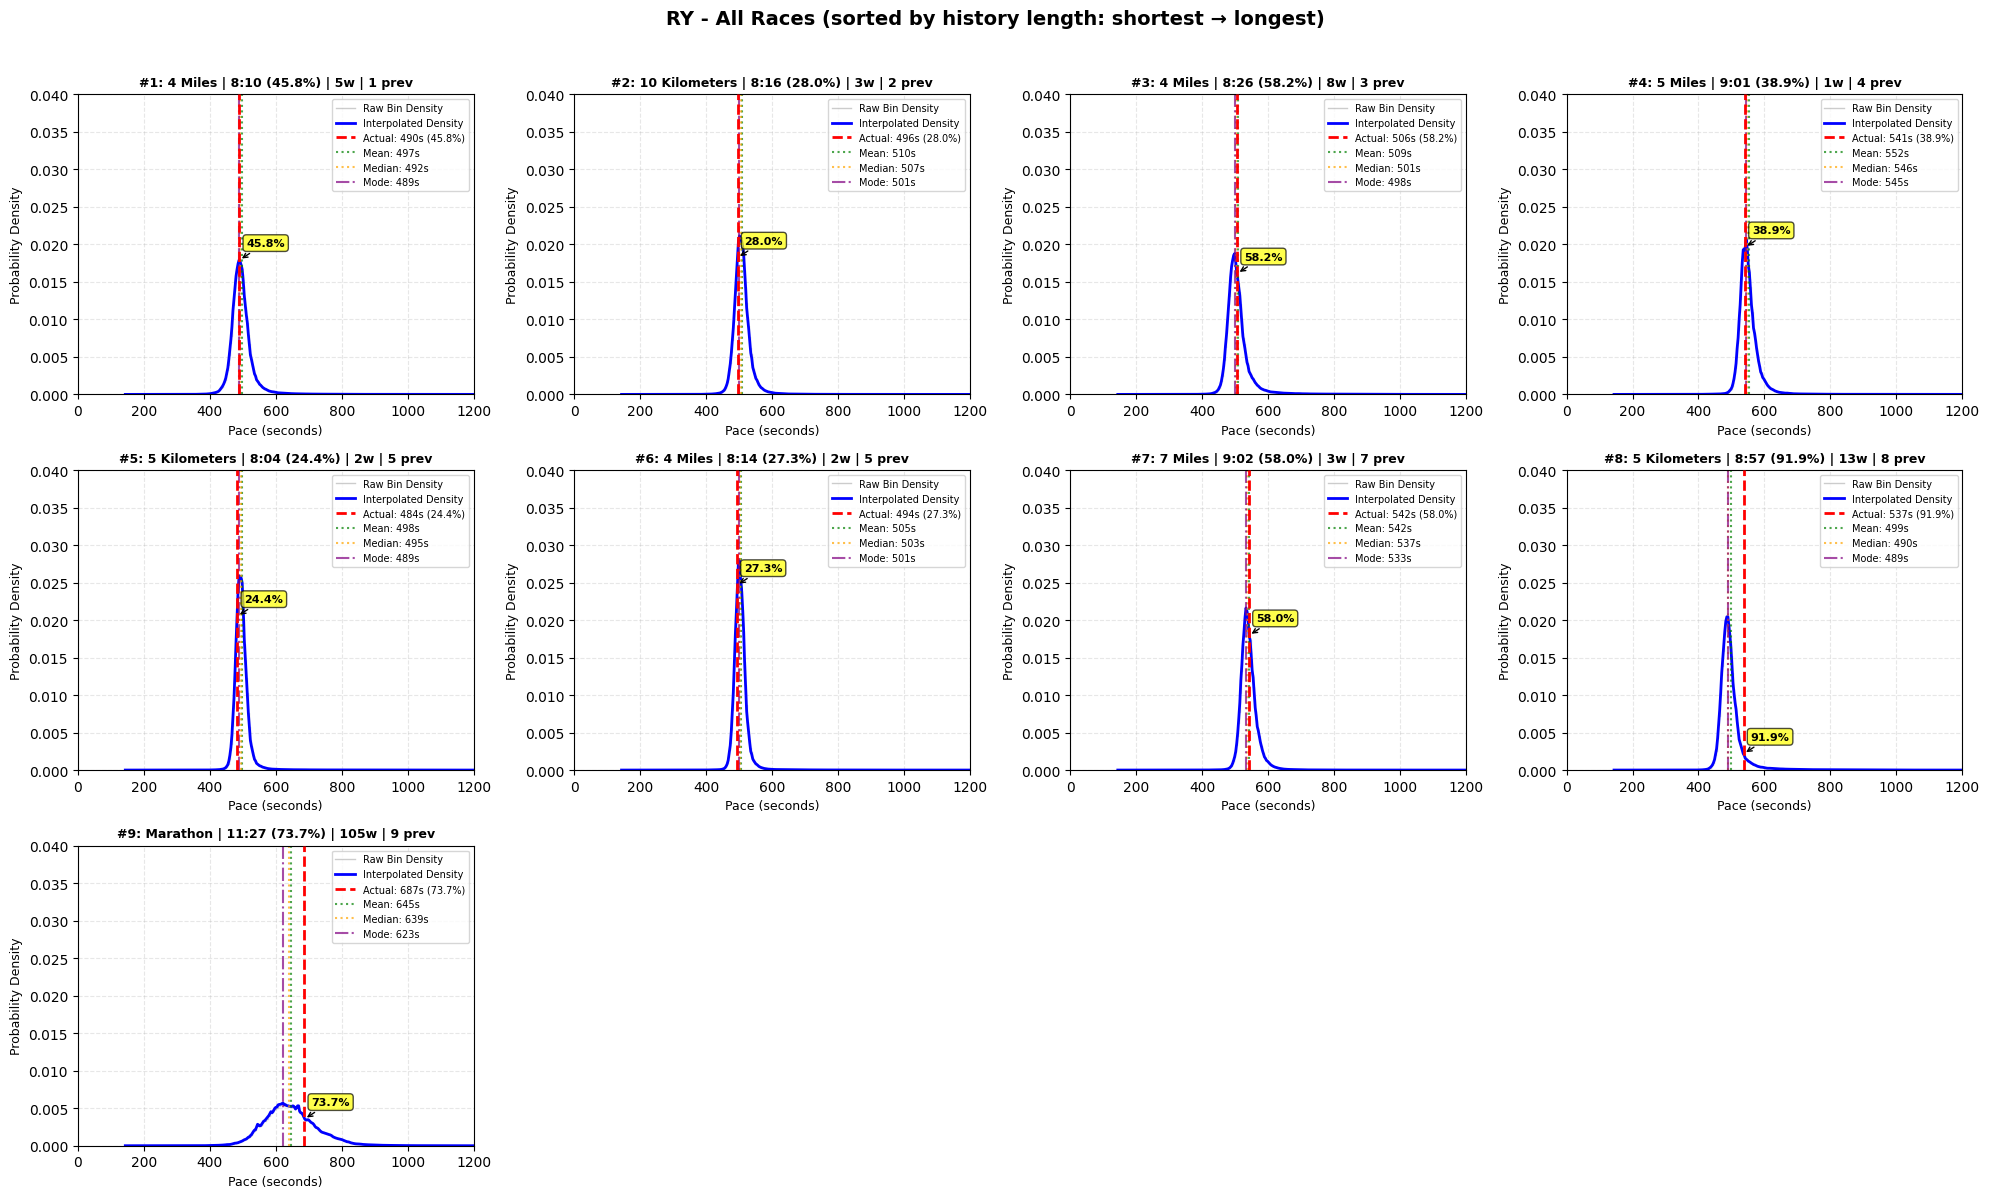


PLOTTING TRAJECTORIES FOR: YE (Yael Elmatad)
Total examples: 29

  Example 1: 1 Mile | 7:11 (431.0s) | 16w | 73.4th percentile
  Example 2: 10 Kilometers | 8:25 (505.0s) | 13w | 40.2th percentile
  Example 3: Half Marathon | 9:24 (564.0s) | 1w | 86.9th percentile
  Example 4: 4 Miles | 8:01 (481.0s) | 1w | 26.7th percentile
  Example 5: 10 Kilometers | 9:03 (543.0s) | 3w | 94.9th percentile
  Example 6: Half Marathon | 9:07 (547.0s) | 1w | 53.4th percentile
  Example 7: 4 Miles | 12:43 (763.0s) | 2w | 99.4th percentile
  Example 8: 5 Kilometers | 7:50 (470.0s) | 2w | 4.3th percentile
  Example 9: 10 Kilometers | 8:32 (512.0s) | 1w | 47.6th percentile
  Example 10: 4 Miles | 8:47 (527.0s) | 5w | 66.4th percentile
  Example 11: 18 Miles | 10:38 (638.0s) | 10w | 86.1th percentile
  Example 12: 1 Mile | 6:42 (402.0s) | 10w | 29.7th percentile
  Example 13: 4 Miles | 9:26 (566.0s) | 30w | 91.0th percentile
  Example 14: 1 Mile | 6:52 (412.0s) | 22w | 38.7th percentile
  Example 15: 5 Kilom

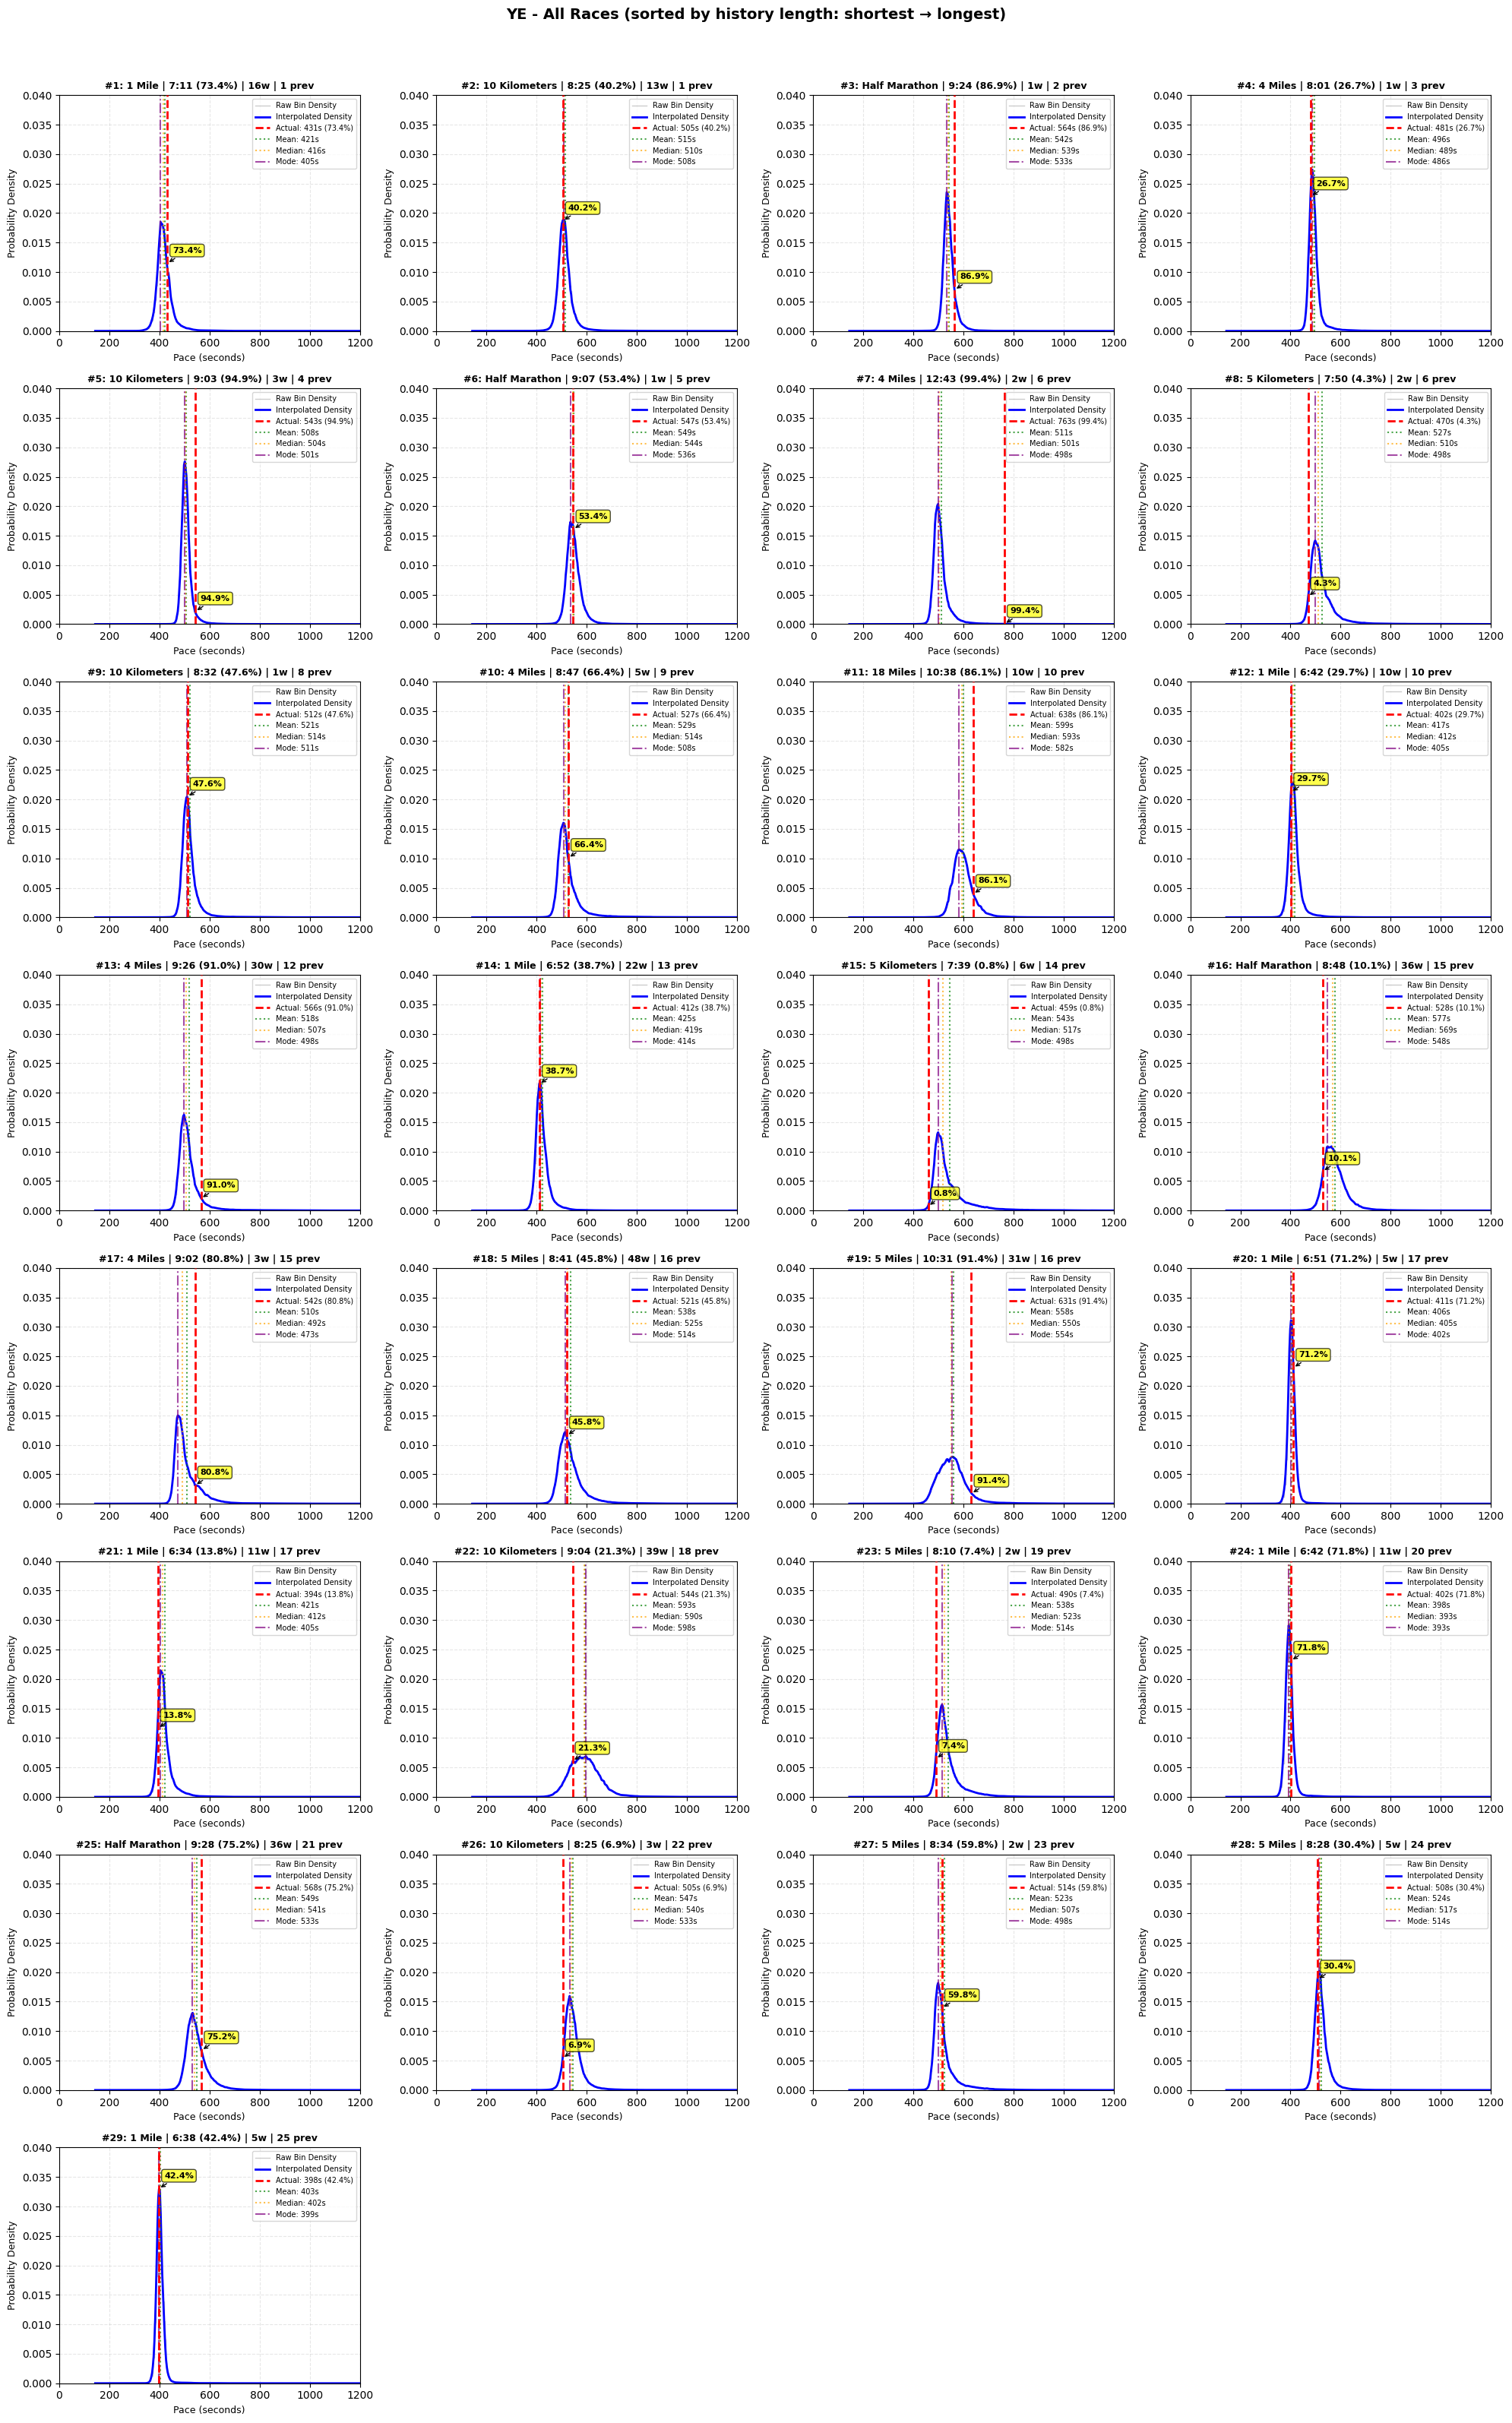


PLOTTING TRAJECTORIES FOR: RW (Rafal Wojdyla)
Total examples: 13

  Example 1: 5 Miles | 7:14 (434.0s) | 13w | 22.3th percentile
  Example 2: 5 Kilometers | 7:17 (437.0s) | 1w | 95.8th percentile
  Example 3: 1 Mile | 6:00 (360.0s) | 2w | 76.4th percentile
  Example 4: 10 Miles | 6:56 (416.0s) | 2w | 0.3th percentile
  Example 5: 10 Kilometers | 6:55 (415.0s) | 1w | 26.2th percentile
  Example 6: Half Marathon | 7:30 (450.0s) | 1w | 81.8th percentile
  Example 7: 5 Miles | 7:03 (423.0s) | 3w | 65.1th percentile
  Example 8: Marathon | 8:29 (509.0s) | 1w | 77.1th percentile
  Example 9: 4 Miles | 6:37 (397.0s) | 16w | 11.0th percentile
  Example 10: 4 Miles | 16:10 (970.0s) | 20w | 100.0th percentile
  Example 11: 10 Miles | 7:06 (426.0s) | 11w | 47.5th percentile
  Example 12: Marathon | 10:57 (657.0s) | 5w | 93.6th percentile
  Example 13: Marathon | 8:00 (480.0s) | 52w | 15.6th percentile


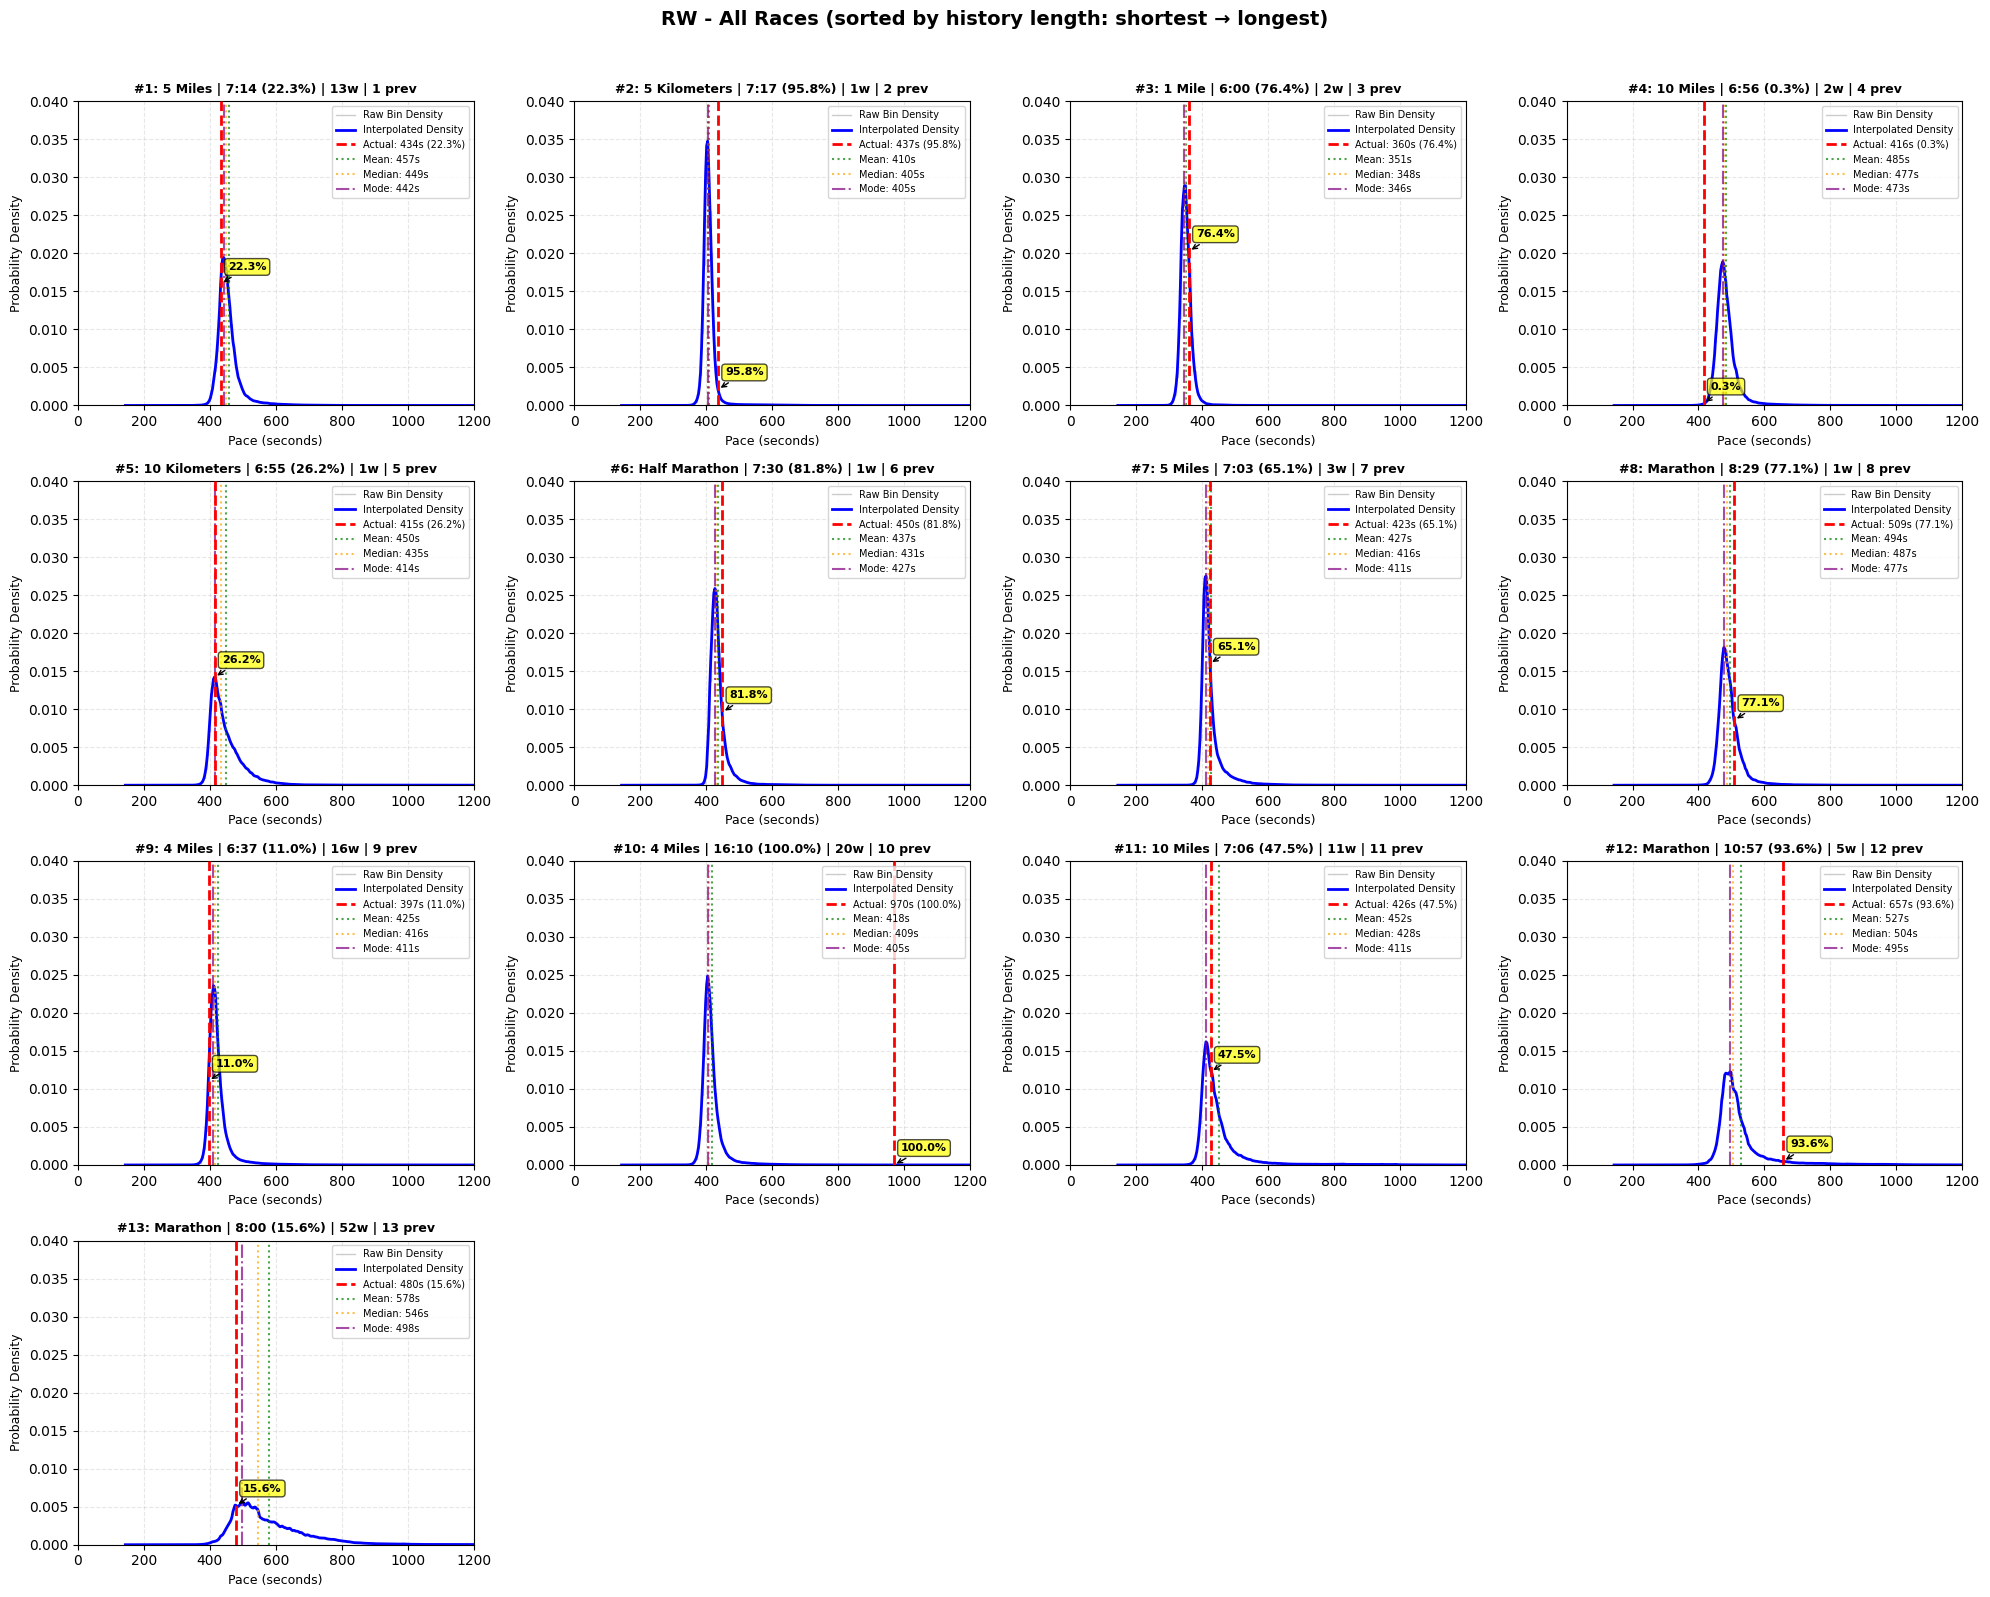

In [30]:
# Plot all training examples for each runner in a grid layout
# Sort by history length (shortest to longest)
# Max 4 plots per row

def get_runner_initials(full_name):
    """Convert full name to initials (e.g., 'Rafal Wojdyla' -> 'RW', 'Romain Yon' -> 'RY')"""
    parts = full_name.split()
    if len(parts) >= 2:
        return f"{parts[0][0]}{parts[1][0]}".upper()
    elif len(parts) == 1:
        return parts[0][0].upper()
    return full_name

for runner_name, runner in found_runners_dict.items():
    runner_initials = get_runner_initials(runner_name)
    print("=" * 80)
    print(f"PLOTTING TRAJECTORIES FOR: {runner_initials} ({runner_name})")
    print(f"Total examples: {len(runner.training_examples)}")
    print("=" * 80)
    print()
    
    # Sort examples by sequence length (shortest history first)
    sorted_examples = sorted(
        [(ex, idx) for idx, ex in enumerate(runner.training_examples, 1) 
         if len(ex.unpadded_example_sequence) >= 11],
        key=lambda x: len(x[0].unpadded_example_sequence)
    )
    
    if not sorted_examples:
        print("No valid examples to plot.")
        print()
        continue
    
    n_examples = len(sorted_examples)
    n_cols = min(4, n_examples)  # Max 4 columns
    n_rows = (n_examples + n_cols - 1) // n_cols  # Ceiling division
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    fig.suptitle(f"{runner_initials} - All Races (sorted by history length: shortest → longest)", 
                 fontsize=14, fontweight='bold', y=0.995)
    
    # Flatten axes array for easier indexing
    # plt.subplots returns different shapes depending on grid size:
    # - Single subplot: returns a single Axes object
    # - Single row: returns a 1D numpy array
    # - Multiple rows: returns a 2D numpy array
    if n_examples == 1:
        axes_flat = [axes]  # Single subplot: wrap in list
    elif n_rows == 1:
        # Single row: convert to list
        axes_flat = [axes] if n_cols == 1 else list(axes)
    else:
        # Multiple rows: flatten 2D array to 1D list
        axes_flat = list(axes.flatten())
    
    # Plot each example in a subplot
    for plot_idx, (ex, original_idx) in enumerate(sorted_examples):
        if plot_idx < len(axes_flat):
            ax = axes_flat[plot_idx]
            quantile = plot_prediction_with_quantile(ex, runner_name=runner_name, 
                                                      example_num=plot_idx+1, ax=ax)
        else:
            print(f"Warning: Skipping example {plot_idx+1} - no subplot available")
    
    # Set consistent axes limits for all subplots
    for ax in axes_flat[:n_examples]:
        ax.set_xlim(0, 1200)
        ax.set_ylim(0, 0.04)
    
    # Hide unused subplots
    for idx in range(n_examples, len(axes_flat)):
        axes_flat[idx].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.98])  # Leave space for suptitle
    plt.show()
    print()
